In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Supermart Grocery Sales.csv')

In [3]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


data cleaning

In [6]:
#change date column from object to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

In [7]:
df.dtypes

Order ID                 object
Customer Name            object
Category                 object
Sub Category             object
City                     object
Order Date       datetime64[ns]
Region                   object
Sales                     int64
Discount                float64
Profit                  float64
State                    object
dtype: object

In [8]:
df.describe()

,Order Date,Sales,Discount,Profit
count,9994,9994.000000,9994.000000,9994.000000
mean,2017-04-11 12:33:42.973784064,1496.596158,0.226817,374.937082
min,2015-01-02 00:00:00,500.000000,0.100000,25.250000
25%,2016-05-01 00:00:00,1000.000000,0.160000,180.022500
50%,2017-05-30 00:00:00,1498.000000,0.230000,320.780000
75%,2018-04-09 00:00:00,1994.750000,0.290000,525.627500
max,2018-12-30 00:00:00,2500.000000,0.350000,1120.950000
std,NaN,577.559036,0.074636,239.932881


EDA

In [10]:
#total revenue
np.sum(df['Sales'])

14956982

In [11]:
#total profit
np.sum(df['Profit'])

3747121.2

matplotlib

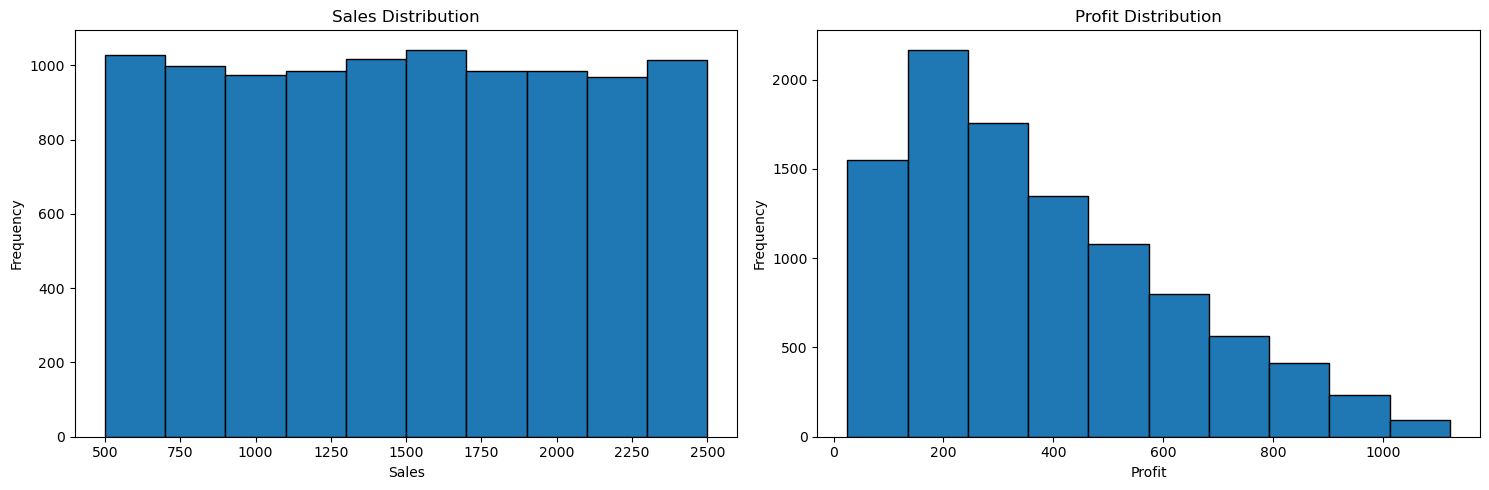

In [13]:
#sales and profit distribution

# Create 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sales distribution
axes[0].hist(df['Sales'], bins=10, edgecolor='black')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Profit distribution
axes[1].hist(df['Profit'], bins=10, edgecolor='black')
axes[1].set_title('Profit Distribution')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('Frequency')

plt.tight_layout()  # Adjust spacing
plt.show()

These histograms shows the sales and profit distribution.

The sales distribution shows the frequency of sales amounts, which range from 500 to 2500.
This data exhibits a relatively even distribution accross most sales ranges.

The profit distribution shows the frequency of profit amounts, which range from 0 to 1000.
The distribution apprears roughly normal, with highest frequency concentrated in the 200 to 400 profit range.

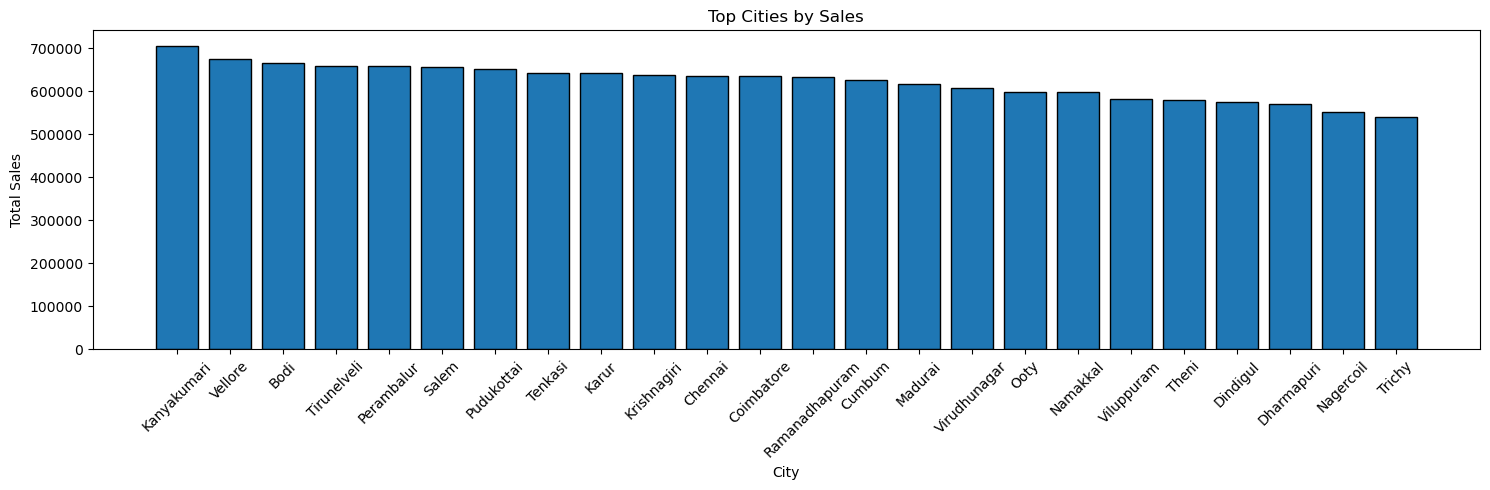

In [15]:
# Group by City and sum Sales
city_sales = df.groupby('City')['Sales'].sum()

# Sort in descending order
city_sales = city_sales.sort_values(ascending=False)

plt.figure(figsize=(15,5))

plt.bar(city_sales.index, city_sales.values, edgecolor='black')

plt.title('Top Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows the total sales grouped by city.

Kanyakumari has the highest total sales and Trichy has the lowest.

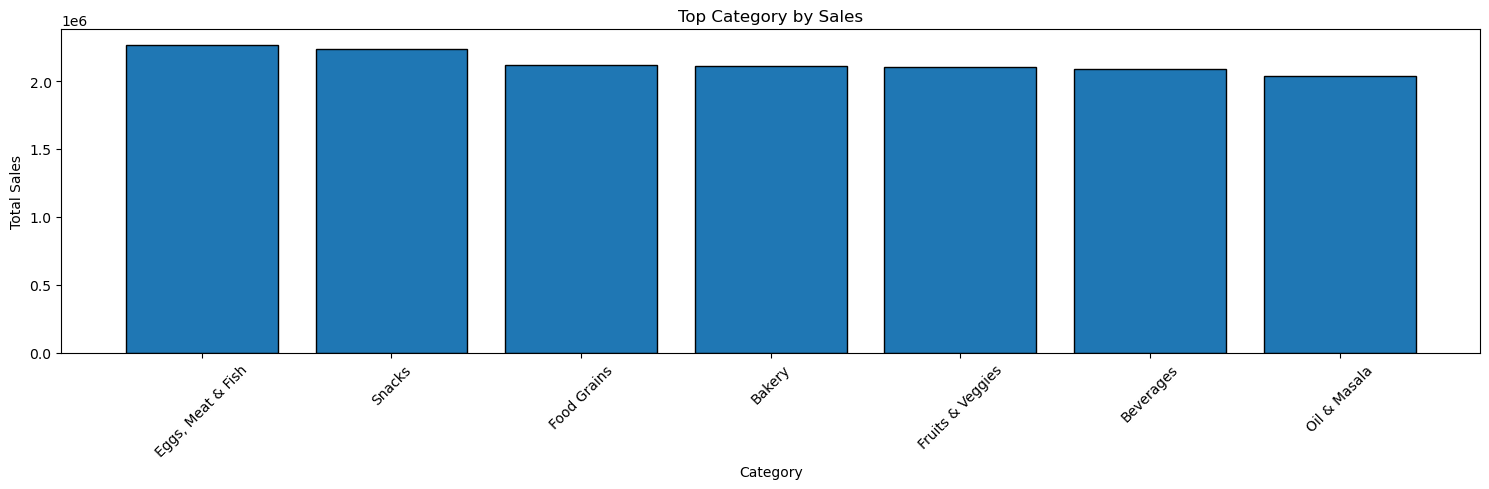

In [17]:
# Group by City and sum Sales
city_sales = df.groupby('Category')['Sales'].sum()

# Sort in descending order
city_sales = city_sales.sort_values(ascending=False)

plt.figure(figsize=(15,5))

plt.bar(city_sales.index, city_sales.values, edgecolor='black')

plt.title('Top Category by Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows the total sales across seven different product categories.

"Eggs, Meat & Fish" represents the top category by sales volume and "Oil & Masala" category has the lowest sales.

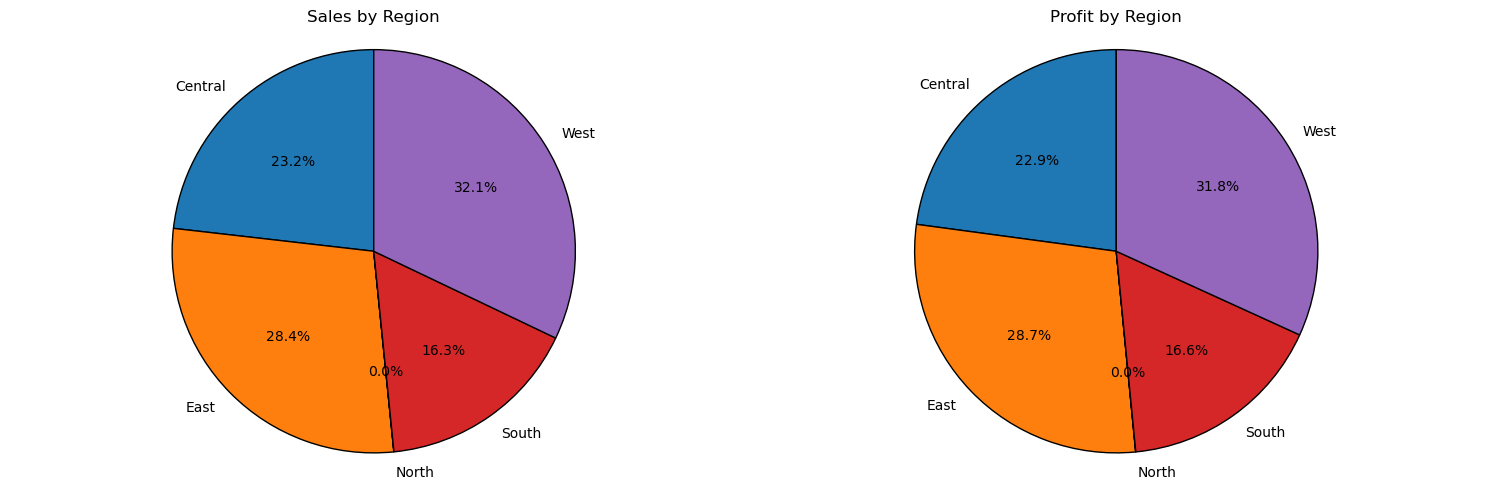

In [19]:
# Aggregate data
region_sales = df.groupby('Region')['Sales'].sum()
region_profit = df.groupby('Region')['Profit'].sum()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sales Pie Chart
axes[0].pie(region_sales,
            labels=region_sales.index,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Sales by Region')
axes[0].axis('equal')

# Profit Pie Chart
axes[1].pie(region_profit,
            labels=region_profit.index,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Profit by Region')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

These pie charts show that the Central and West regions are the top performers in both sales and profit percentages, while the North and South regions have the lowest contributions.